<a href="https://colab.research.google.com/github/Kamranmaster/Modified_Fire_Hawk_Optimisation/blob/main/IRIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/ML dataset/Iris.csv')
import seaborn as sns


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [6]:
df.duplicated().sum()

np.int64(0)

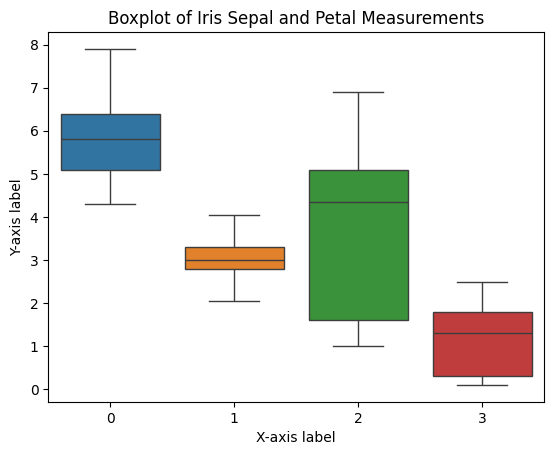

In [16]:
import matplotlib.pyplot as plt

data_columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm","PetalWidthCm"]  # List of columns to plot
sns.boxplot(df[data_columns].values)
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")
plt.title("Boxplot of Iris Sepal and Petal Measurements")
plt.show()

Remove The outliner

In [8]:
a=df["SepalWidthCm"].quantile(0.25)
b=df["SepalWidthCm"].quantile(0.75)
iqr=b-a
lower_bound=a-(1.5*iqr)
upper_bound=b+(1.5*iqr)

print("Lower_Bound",lower_bound)
print("Upper_Bound",upper_bound)

Lower_Bound 2.05
Upper_Bound 4.05


In [9]:
outliers=df[(df['SepalWidthCm']<lower_bound) | (df['SepalWidthCm']>upper_bound)]

In [10]:
print(outliers)

    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
15  16            5.7           4.4            1.5           0.4   
32  33            5.2           4.1            1.5           0.1   
33  34            5.5           4.2            1.4           0.2   
60  61            5.0           2.0            3.5           1.0   

            Species  
15      Iris-setosa  
32      Iris-setosa  
33      Iris-setosa  
60  Iris-versicolor  


In [11]:
outliers.shape

(4, 6)

In [12]:
df['SepalWidthCm']=df['SepalWidthCm'].clip(lower=lower_bound,upper=upper_bound)

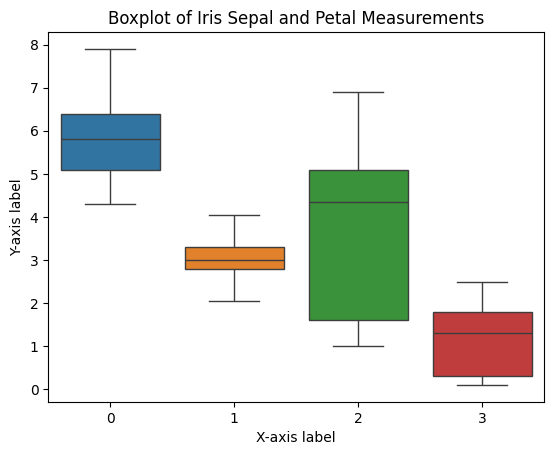

In [13]:
import matplotlib.pyplot as plt

data_columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm","PetalWidthCm"]  # List of columns to plot
sns.boxplot(df[data_columns].values)
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")
plt.title("Boxplot of Iris Sepal and Petal Measurements")
plt.show()

## Convert Categorical data to Numerical data

In [18]:
df['Species']=df['Species'].astype('category').cat.codes

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int8   
dtypes: float64(4), int64(1), int8(1)
memory usage: 6.1 KB


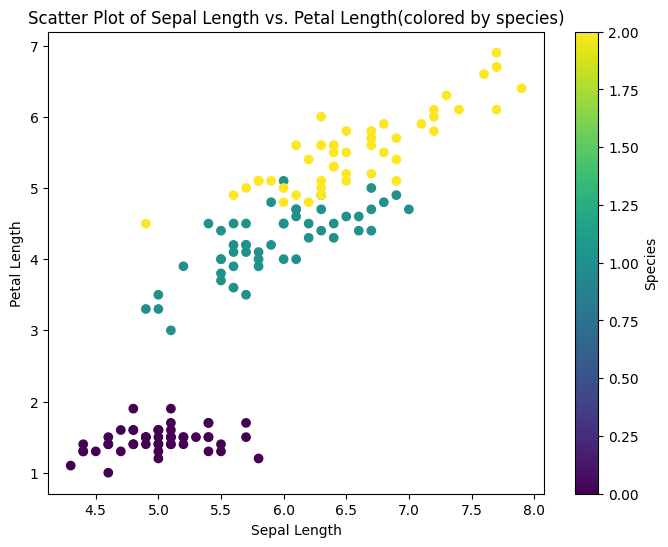

In [20]:
plt.figure(figsize=(8,6))
scatter=plt.scatter(df['SepalLengthCm'],df['PetalLengthCm'],c=df['Species'],cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('Scatter Plot of Sepal Length vs. Petal Length(colored by species)')
plt.colorbar(scatter  ,label='Species')
plt.show()

##Plot Boxplt for the data

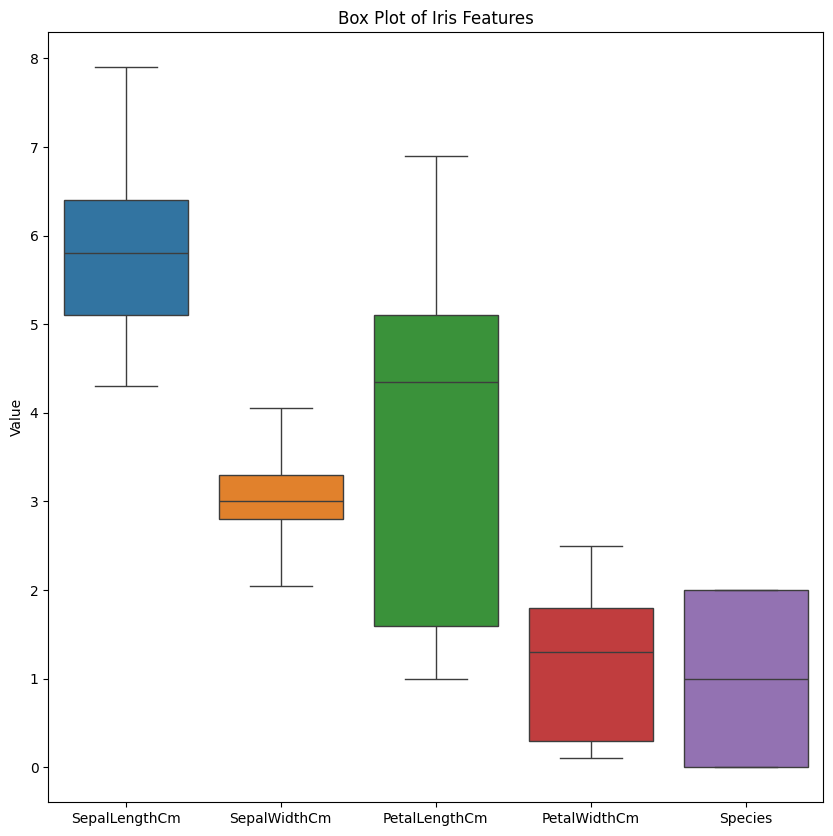

In [23]:
plt.figure(figsize=(10, 10))
sns.boxplot(data=df.drop(columns=['Id'],errors='ignore'))
plt.title("Box Plot of Iris Features")
plt.ylabel('Value')
plt.show()

## Plot Heatmap for the data


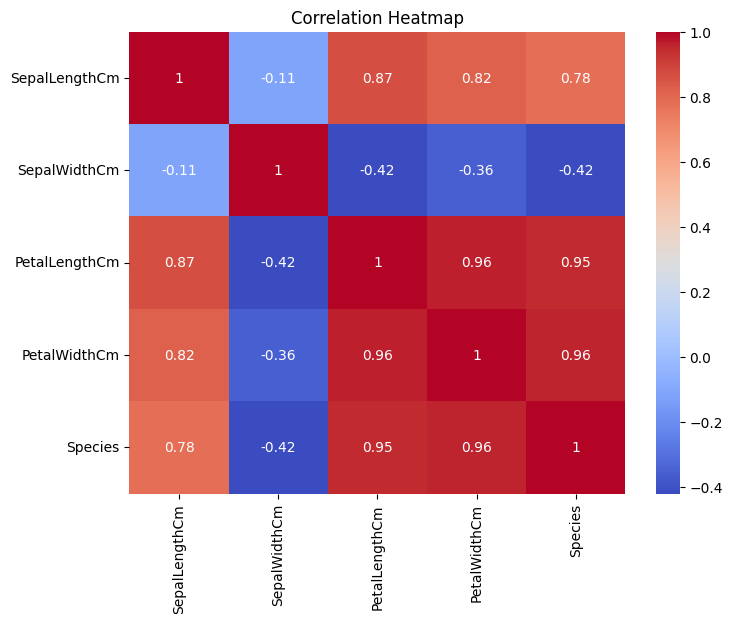


Top 2 Strongest Positive Correlations:
PetalWidthCm   PetalLengthCm    0.962757
PetalLengthCm  PetalWidthCm     0.962757
dtype: float64


In [27]:
plt.figure(figsize=(8, 6))
corr_matrix=df.drop(columns=['Id'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

stacked_corr = corr_matrix.stack()
stacked_corr = stacked_corr[stacked_corr.index.get_level_values(0) != stacked_corr.index.get_level_values(1)]
sorted_corr = stacked_corr.sort_values(ascending=False)
top_2_positive_correlations = sorted_corr.head(2)
print("\nTop 2 Strongest Positive Correlations:")
print(top_2_positive_correlations)